# 03 - Numerical Stability & Bayesian Foundations

Part of the Advanced Optimization & Numerical Methods subchapter. Two groups of topics that round out the math chapter: numerical stability (the gap between mathematically-correct and computationally-correct, which matters constantly at companies where you are close to the hardware/kernel level) and the Bayesian framing of probability, extending the Statistics subchapter's Bayes' theorem and MLE/MAP notebooks. Law of Large Numbers included here alongside the Bayesian material since it is the theorem that justifies estimating a probability by observed frequency in the first place.

No book citation for the numerical-stability content -- standard software-engineering/numerical-computing knowledge rather than textbook material. The Bayesian material extends *Mathematics for Machine Learning* §6.1-6.4 (Statistics subchapter, notebook 01) and §8.3 (notebook 02).

# Part A - Numerical Stability

Mathematically equivalent formulas can behave completely differently in floating point. Every failure below is real, not illustrative -- run as written, with no special setup.

### Softmax overflow

`exp()` of a large number overflows a float64 long before the softmax's actual output (which is always between 0 and 1) would suggest any problem.

In [ ]:
import numpy as np

logits = np.array([1000., 1001., 1002.])

with np.errstate(over="ignore", invalid="ignore"):
    naive = np.exp(logits) / np.sum(np.exp(logits))
print("naive softmax:", naive, " <- silently NaN, not an error, not a warning you'd necessarily notice")

def softmax_stable(x):
    z = x - np.max(x)      # shift so the largest value is exactly 0 before exponentiating
    e = np.exp(z)
    return e / np.sum(e)

print("stable softmax:", softmax_stable(logits))

naive softmax: [nan nan nan]  <- silently NaN, not an error, not a warning you'd necessarily notice
stable softmax: [0.09003057 0.24472847 0.66524096]


**Why subtracting the max fixes it, without changing the answer:** `softmax(x)_i = exp(x_i) / Σexp(x_j) = exp(x_i - c) / Σexp(x_j - c)` for ANY constant `c` -- the `exp(c)` factor cancels top and bottom. Choosing `c = max(x)` guarantees the largest exponent computed is `exp(0) = 1`, so nothing can overflow, and the math is provably identical.

### log-sum-exp: the same trick, one level up

`log(Σexp(xᵢ))` shows up constantly (the normalizing constant of a softmax in log-space, the denominator of a log-likelihood over a mixture model). Same overflow problem, same fix.

In [ ]:
def logsumexp_naive(x):
    return np.log(np.sum(np.exp(x)))

def logsumexp_stable(x):
    m = np.max(x)
    return m + np.log(np.sum(np.exp(x - m)))

x = np.array([1000., 1001., 1002.])
with np.errstate(over="ignore", invalid="ignore"):
    print("naive:  ", logsumexp_naive(x))
print("stable: ", logsumexp_stable(x))

from scipy.special import logsumexp as scipy_lse
print("scipy (same trick internally):", scipy_lse(x))

naive:   inf
stable:  1002.4076059644444


scipy (same trick internally): 1002.4076059644444


### Catastrophic cancellation

Subtracting two nearly-equal large floating point numbers can destroy almost all of the meaningful precision -- not a large-number problem specifically, a "the answer is small but computed as a difference of large things" problem.

In [ ]:
a = 1e16
b = 1.0
print("mathematically, (a + b) - a should equal", b)
print("in float64, it actually equals:            ", (a + b) - a)
print("b was completely absorbed -- float64 only has ~16 significant decimal digits,")
print("and a+b needed all of them just to represent a, leaving none for b")

mathematically, (a + b) - a should equal 1.0
in float64, it actually equals:             0.0
b was completely absorbed -- float64 only has ~16 significant decimal digits,
and a+b needed all of them just to represent a, leaving none for b


### Comparing floats for equality

The single most common float bug: `==` on two values that are mathematically equal but were computed via different floating-point paths.

In [ ]:
print("0.1 + 0.2 == 0.3:", 0.1 + 0.2 == 0.3)
print("actual difference:  ", (0.1 + 0.2) - 0.3)

import math
print("correct approach -- math.isclose:", math.isclose(0.1 + 0.2, 0.3))

0.1 + 0.2 == 0.3: False
actual difference:   5.551115123125783e-17
correct approach -- math.isclose: True


### Where this shows up in ML code specifically

- Cross-entropy loss is `-log(softmax(logits))` -- nearly every deep learning framework fuses this into a single `log_softmax` / `cross_entropy` op internally specifically to apply the log-sum-exp trick once, rather than computing softmax then taking a log of a possibly-tiny or possibly-NaN number.
- Variance/std computed as `E[X²] - E[X]²` (the "naive" formula) can go slightly negative due to cancellation for low-variance data, then crash `sqrt()` -- the numerically stable alternative (Welford's algorithm) accumulates variance incrementally without ever computing that difference of two large, close numbers.
- Mixed-precision training (fp16/bf16) makes every issue on this page dramatically more likely, since those formats have far less precision than float64 -- this is exactly why loss scaling exists in mixed-precision training recipes.

# Part B - Law of Large Numbers vs. Central Limit Theorem

Both describe repeated sampling, and they are constantly confused for each other -- they answer different questions.

- **LLN**: the sample mean converges to the true mean as `n → ∞`. Says nothing about the shape of the fluctuations along the way, only that they vanish eventually.
- **CLT** (Statistics subchapter, notebook 02): the DISTRIBUTION of the sample mean, appropriately rescaled, approaches a Gaussian as `n → ∞` -- a statement about shape, not just convergence.

LLN is *why* estimating a probability by observed frequency (e.g. MLE, notebook 02) is justified at all; CLT is *why* the resulting estimate's own uncertainty is well-approximated by a Gaussian, which is what confidence intervals (Statistics notebook 03) rely on.

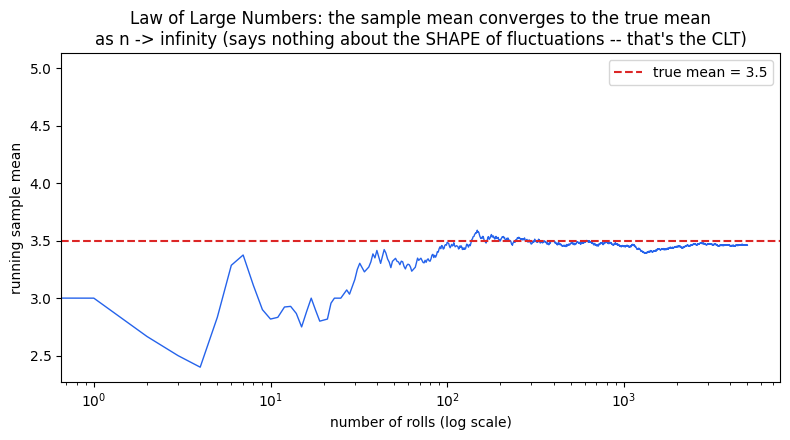

running mean after 5000 rolls: 3.4608 (true mean: 3.5)


In [ ]:
rng = np.random.default_rng(3)
true_mean = 3.5   # a fair 6-sided die
rolls = rng.integers(1, 7, size=5000)
running_mean = np.cumsum(rolls) / np.arange(1, 5001)

import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(running_mean, color="#2563eb", linewidth=1)
ax.axhline(true_mean, color="#dc2626", linestyle="--", label=f"true mean = {true_mean}")
ax.set_xscale("log")
ax.set_xlabel("number of rolls (log scale)")
ax.set_ylabel("running sample mean")
ax.legend()
ax.set_title("Law of Large Numbers: the sample mean converges to the true mean\nas n -> infinity (says nothing about the SHAPE of fluctuations -- that's the CLT)")
fig.tight_layout()
fig.savefig(FIG_DIR / "lln_convergence.png", dpi=140)
plt.show()
print("running mean after 5000 rolls:", round(running_mean[-1], 4), "(true mean: 3.5)")

# Part C - Bayesian Probability, as a Sequential Process

The Statistics subchapter covered Bayes' theorem and, separately, MAP as "MLE plus a prior." The genuinely Bayesian framing goes further: probability represents a DEGREE OF BELIEF that gets updated as evidence arrives, and updating can happen one observation at a time -- today's posterior becomes tomorrow's prior.

### Frequentist vs. Bayesian, in one line each

- **Frequentist**: a parameter has one true, fixed, unknown value; probability describes long-run frequency over repeated experiments. A confidence interval's "95%" describes the reliability of the *procedure* (Statistics notebook 03), not a probability statement about the specific parameter.
- **Bayesian**: a parameter is treated as a random variable with a distribution reflecting current belief; probability describes degree of belief, which is why a **credible interval** ("there is a 95% probability the parameter lies in this range, given the data and the prior") is a directly different, and for many people more intuitive, statement than a confidence interval -- but it depends on the prior chosen, which a confidence interval does not.

### Sequential updating: Beta-Bernoulli, one flip at a time

Estimating a coin's bias `p`. The Beta distribution is the conjugate prior for a Bernoulli/Binomial likelihood (mirrors the Gaussian-Gaussian conjugacy in the Statistics MLE/MAP notebook): starting from `Beta(α, β)`, observing `k` heads in `n` flips gives posterior `Beta(α+k, β+n-k)` -- a closed-form update, no numerical integration needed, and each posterior becomes the prior for the next batch of data.

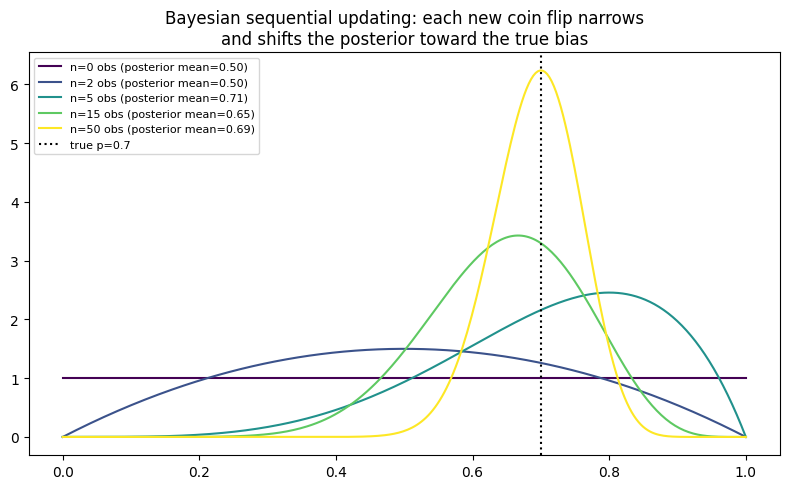

posterior mean after 50 flips: 0.692  (true p = 0.7)


In [ ]:
from scipy.stats import beta as beta_dist

true_p = 0.7
flips = rng.binomial(1, true_p, size=50)

alpha0, beta0 = 1, 1   # Beta(1,1) = uniform prior -- "no strong belief either way"
xs = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(8, 5))
checkpoints = [0, 2, 5, 15, 50]
colors = plt.cm.viridis(np.linspace(0, 1, len(checkpoints)))
for i, n in enumerate(checkpoints):
    a = alpha0 + flips[:n].sum()
    b = beta0 + n - flips[:n].sum()
    ax.plot(xs, beta_dist.pdf(xs, a, b), color=colors[i], label=f"n={n} obs (posterior mean={a/(a+b):.2f})")
ax.axvline(true_p, color="black", linestyle=":", label=f"true p={true_p}")
ax.legend(fontsize=8)
ax.set_title("Bayesian sequential updating: each new coin flip narrows\nand shifts the posterior toward the true bias")
fig.tight_layout()
fig.savefig(FIG_DIR / "bayesian_updating.png", dpi=140)
plt.show()

final_mean = (alpha0 + flips.sum()) / (alpha0 + beta0 + 50)
print(f"posterior mean after 50 flips: {final_mean:.3f}  (true p = {true_p})")

Two things worth having ready:
- The posterior after `n=0` observations IS the prior -- Bayesian updating is not a separate machine bolted onto a prior, the prior is just the `n=0` case of the same update rule.
- As `n` grows, the posterior narrows and the CHOICE of prior matters less and less -- with enough data, a reasonable prior and a very different reasonable prior converge to nearly the same posterior. This is the practical resolution to "isn't the prior just subjective" objections: it matters most exactly when data is scarce, which is also exactly when MAP's shrinkage toward the prior (Statistics notebook 02) is most useful.

## Self-check before moving on

- [ ] I can explain why subtracting the max before exponentiating leaves softmax's value unchanged
- [ ] I can implement the log-sum-exp trick and explain what problem it solves
- [ ] I can give an example of catastrophic cancellation and why it is a "small answer, large intermediate values" problem
- [ ] I can state the difference between the Law of Large Numbers and the Central Limit Theorem in one sentence each
- [ ] I can state the Frequentist vs. Bayesian distinction, and the confidence-interval vs. credible-interval distinction
- [ ] I can explain Bayesian updating as sequential, with today's posterior becoming tomorrow's prior

This closes out Advanced Optimization & Numerical Methods, and with it, the full Mathematical Foundations chapter.